In [1]:
import json
import numpy as np
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from ND2.utils.plot import get_fig

result = pd.read_json('./result/unknown_network.json')

In [2]:
for i in result['result']:
    print(i[:4] + ['<Ce>'] + i[5:], len(i[4]))

['add', 'omega', 'aggr', 'mul', '<Ce>', 'sin', 'sub', 'targ', 'x', 'sour', 'x'] 90
['add', 'omega', 'aggr', 'mul', '<Ce>', 'sin', 'sub', 'targ', 'x', 'sour', 'x'] 90
['add', 'omega', 'aggr', 'mul', '<Ce>', 'sin', 'sub', 'targ', 'x', 'sour', 'x'] 90
['add', 'omega', 'aggr', 'mul', '<Ce>', 'sin', 'sub', 'targ', 'x', 'sour', 'x'] 55460
['add', 'omega', 'aggr', 'mul', '<Ce>', 'sin', 'sub', 'targ', 'x', 'sour', 'x'] 55460
['add', 'omega', 'aggr', 'mul', '<Ce>', 'sin', 'sub', 'targ', 'x', 'sour', 'x'] 55460
['add', 'omega', 'aggr', 'mul', '<Ce>', 'sin', 'sub', 'sour', 'x', 'targ', 'x'] 55460


/tmp/ipykernel_3351755/4124311019.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result, x='name', y='success', ax=ax, palette='Set2', capsize=0.1)
/tmp/ipykernel_3351755/4124311019.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Network\n(V=10)', 'Network 2\n(V=236)'])
/tmp/ipykernel_3351755/4124311019.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result, x='name', y='episode', ax=ax, palette='Set2', capsize=0.1)
/tmp/ipykernel_3351755/4124311019.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or 

name
unknown_network_kuramoto_BA10_BIC     0.612337
unknown_network_kuramoto_BIC         22.501522
Name: time, dtype: float64


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


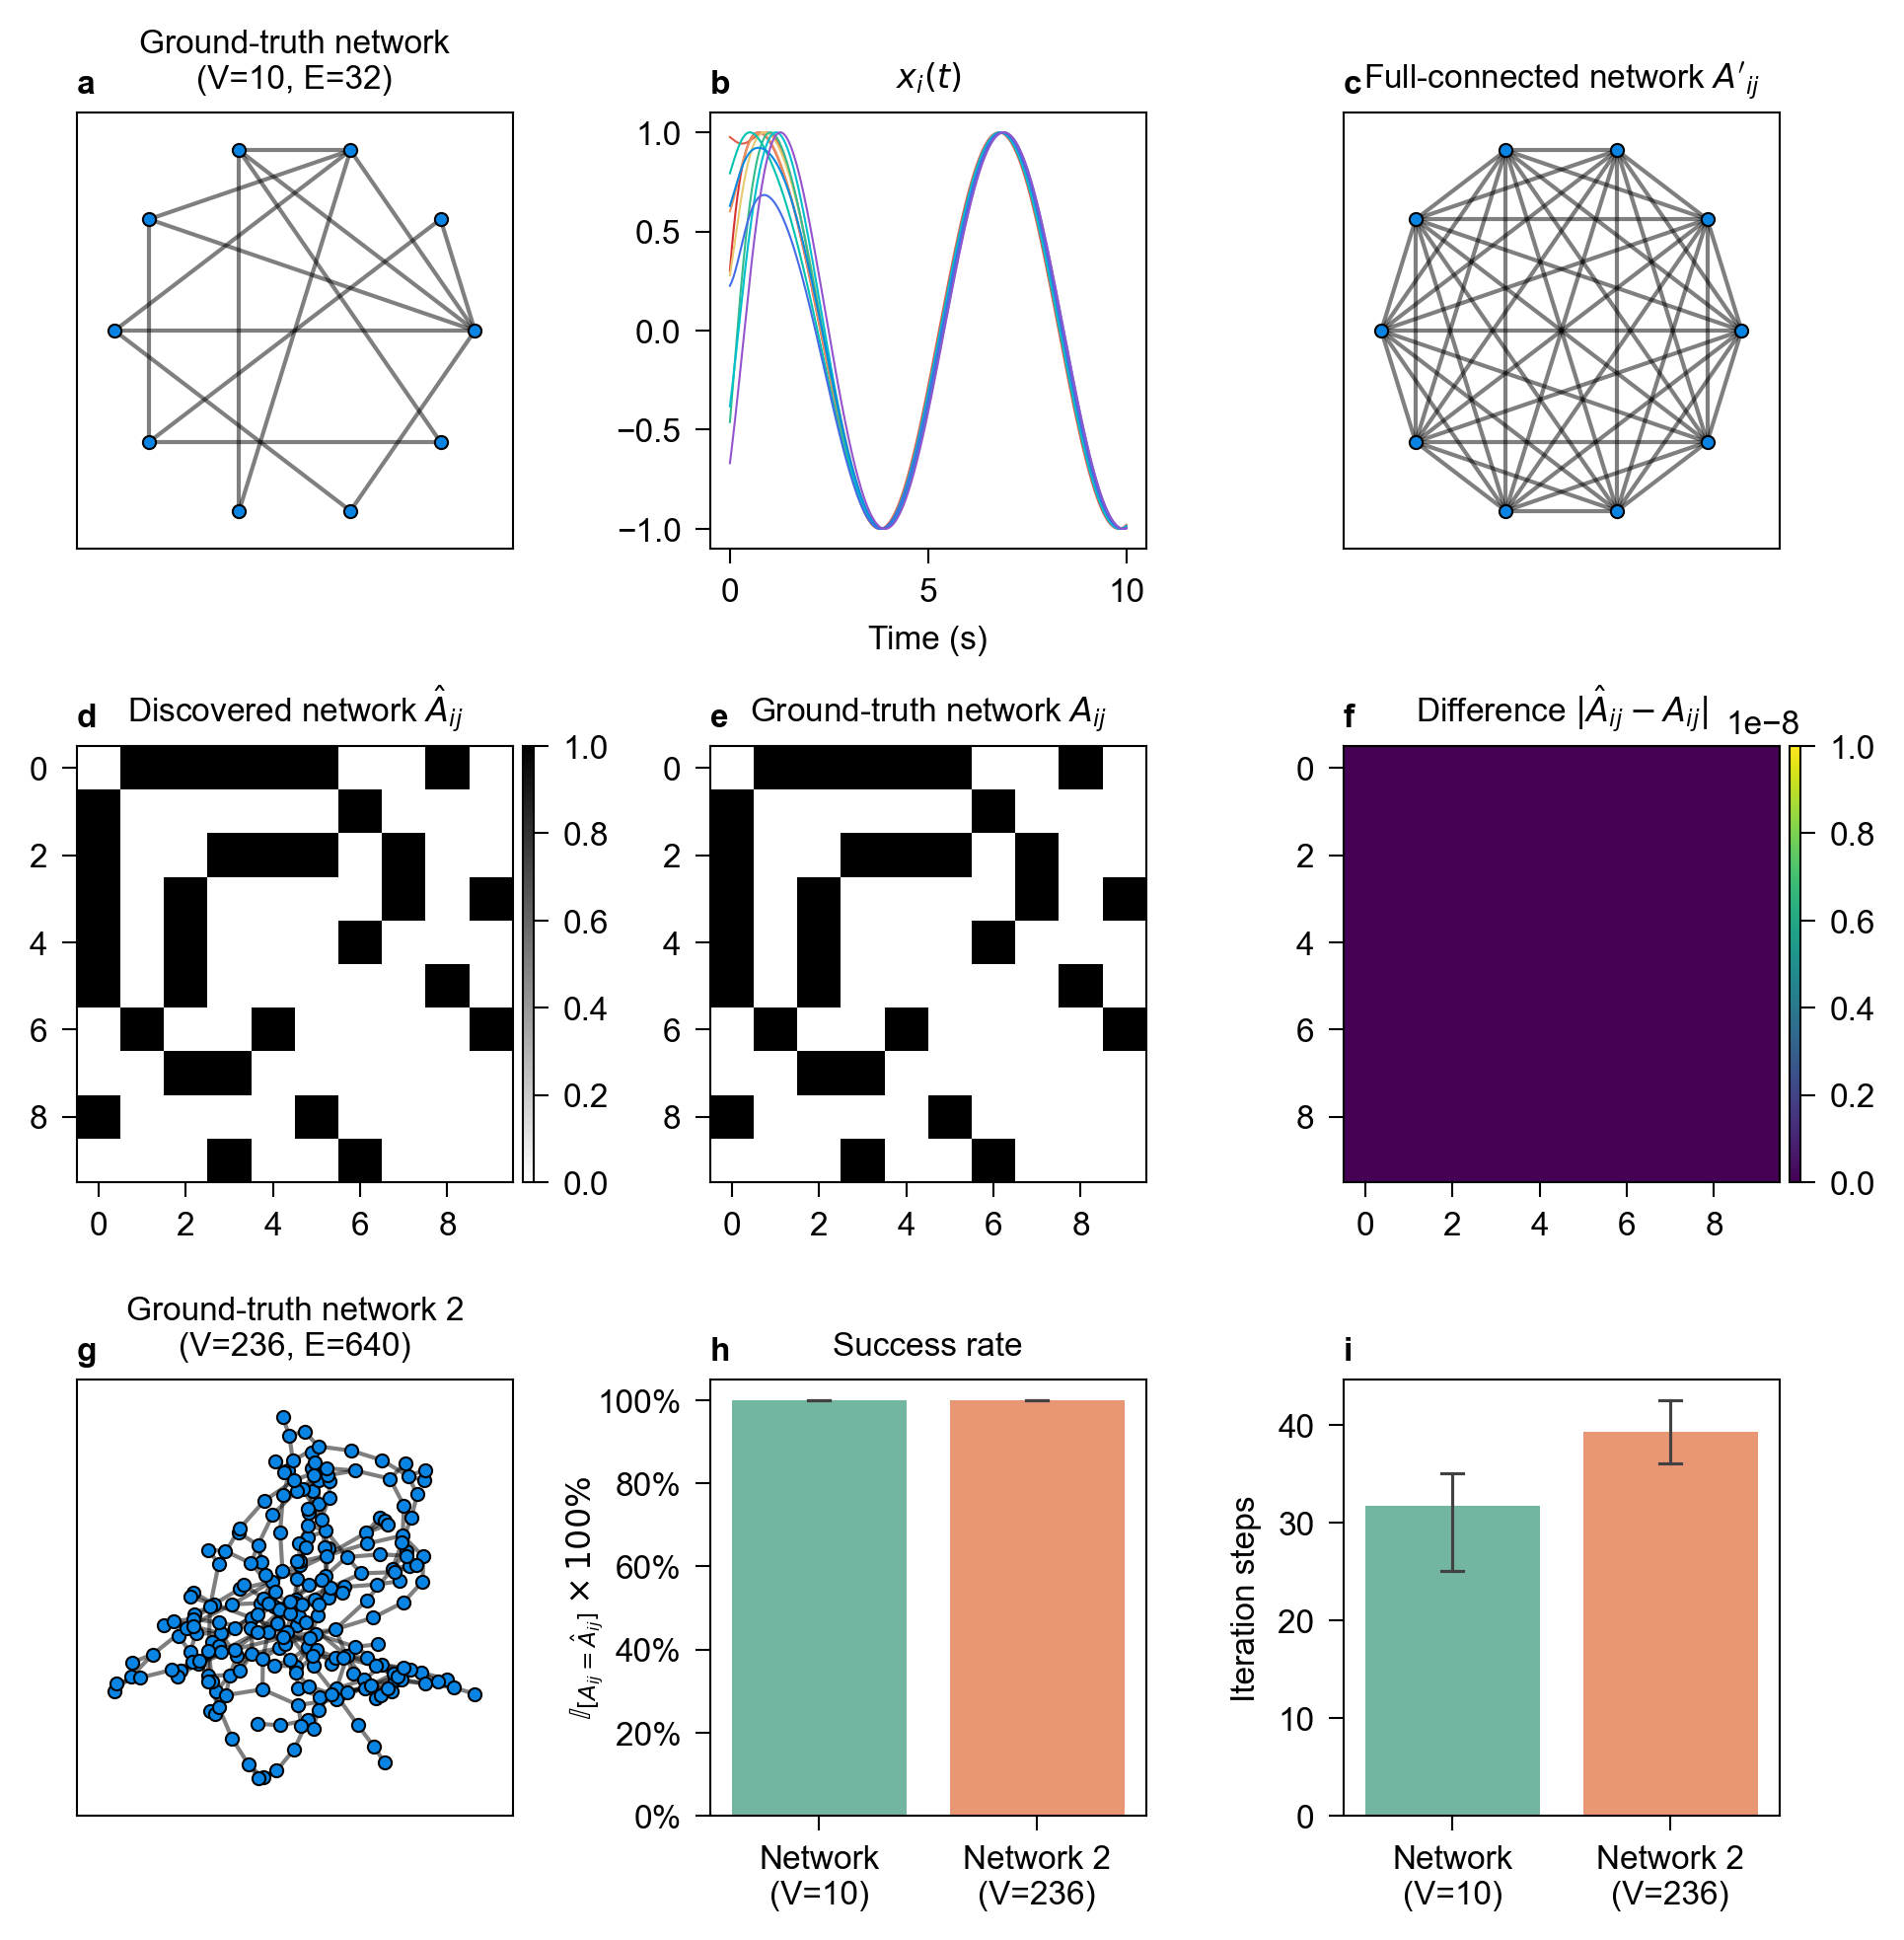

In [3]:
fi, fig, axes = get_fig(3, 3, FH=18, LM=6, TM=6, RM=6, BM=6, fontsize=8)

# 读取 BA10 数据
data = json.load(open('./data/unknown_network/kuramoto_BA10.json', 'r'))
A = np.array(data['A'])
G = np.array(data['G'])
omega = np.array(data['omega'])[0]
A0 = np.ones_like(A) - np.eye(A.shape[0])
G0 = np.stack(np.nonzero(A0), axis=-1)

# 绘制 Graph
ax = axes[0]
import networkx as nx
graph = nx.from_numpy_array(A)
pos = nx.circular_layout(graph)
nx.draw_networkx_edges(graph, pos, ax=ax, edge_color='k', alpha=0.5)
nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=10, node_color='#0984e3', alpha=1.0, edgecolors='k', linewidths=0.5)
ax.set_title(f'Ground-truth network\n(V={A.shape[0]}, E={A.sum():.0f})')

# 绘制 Dynamics
ax = axes[1]
from matplotlib.colors import LinearSegmentedColormap
N = 10
time = np.arange(1000) * 0.01
cmap = LinearSegmentedColormap.from_list('my_hsv', ['#d63031', '#e17055', '#fdcb6e', '#00b894', '#00cec9', '#0984e3' ,'#6c5ce7', '#e84393'])
for i in range(N):
    ax.plot(time, np.sin(data['x'])[:, i], label=f'Node {i+1}', color=cmap(i/N))
for i in range(N, A.shape[0]):
    ax.plot(time, np.sin(data['x'])[:, i], color='#b2bec3', alpha=0.3, zorder=-100000)
ax.set_title('$x_i(t)$')
ax.set_xlabel('Time (s)')

# 绘制全连接网络
ax = axes[2]
graph = nx.from_numpy_array(A0)
pos = nx.circular_layout(graph)
nx.draw_networkx_edges(graph, pos, ax=ax, edge_color='k', alpha=0.5)
nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=10, node_color='#0984e3', alpha=1.0, edgecolors='k', linewidths=0.5)
ax.set_title('Full-connected network $A\'_{ij}$')

# 绘制发现的网络
ax = axes[3]
cax = fig.add_axes([ax.get_position().x1+0.005, ax.get_position().y0, 0.005, ax.get_position().height])
tmp = np.zeros(A.shape)
tmp[G0[:, 0], G0[:, 1]] = -np.array(result.loc[0, 'result'][4])
ax.imshow(tmp, cmap='binary')
plt.colorbar(cax=cax, mappable=ax.images[0])
ax.set_title('Discovered network $\\hat{A}_{ij}$')
ax.set_xticks([0, 2, 4, 6, 8])

# 绘制真实的网络
ax = axes[4]
ax.imshow(A, cmap='binary')
ax.set_title('Ground-truth network $A_{ij}$')
ax.set_xticks([0, 2, 4, 6, 8])

# 绘制差异
ax = axes[5]
cax = fig.add_axes([ax.get_position().x1+0.005, ax.get_position().y0, 0.005, ax.get_position().height])
tmp = np.abs(tmp - A)
ax.imshow(tmp, cmap='viridis', vmin=0, vmax=1e-8)
plt.colorbar(cax=cax, mappable=ax.images[0])
ax.set_title('Difference $|\\hat{A}_{ij} - A_{ij}|$')
ax.set_xticks([0, 2, 4, 6, 8])

# 更大的网络：拓扑
ax = axes[6]
data = json.load(open('./data/synthetic/KUR.json', 'r'))
A = np.array(data['A'])
graph = nx.from_numpy_array(A)
pos = nx.spring_layout(graph)
nx.draw_networkx_edges(graph, pos, ax=ax, edge_color='k', alpha=0.5)
nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=10, node_color='#0984e3', alpha=1.0, edgecolors='k', linewidths=0.5)
ax.set_title(f'Ground-truth network 2\n(V={A.shape[0]}, E={A.sum():.0f})')

# 成功率
ax = axes[7]
result['success'] = result['ACC4']>0.8
sns.barplot(data=result, x='name', y='success', ax=ax, palette='Set2', capsize=0.1)
ax.set_xticklabels(['Network\n(V=10)', 'Network 2\n(V=236)'])
ax.set_xlabel('')
ax.set_ylabel(r'$\mathbb{I}_{[A_{ij} = \hat{A}_{ij}]} \times 100\%$')
ax.set_title('Success rate')
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.labelpad = -2

# 用时
ax = axes[8]
result['episode'] = [25, 35, 35, 38, 42, 34, 43]
sns.barplot(data=result, x='name', y='episode', ax=ax, palette='Set2', capsize=0.1)
ax.set_xticklabels(['Network\n(V=10)', 'Network 2\n(V=236)'])
ax.set_xlabel('')
ax.set_ylabel('Iteration steps')

print(result.groupby('name')['time'].mean() / 60)

for idx, ax in enumerate(axes):
    ax.text(0, 1.03, chr(ord('a')+idx), fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)

fig.savefig('./plot/unknown_network/result.pdf', dpi=300, bbox_inches='tight')